# Clasificacion de leads con 5 algoritmos

Este notebook consume los CSV exportados desde la preparacion de datos (`outputs/leads_3000_train.csv` y `outputs/leads_3000_test.csv`), entrena 5 modelos y muestra su `classification report`.

In [1]:
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [2]:
# Cargar datasets (salida de preparacion)
from pathlib import Path

base_dir = Path('outputs')
train_path = base_dir / 'leads_3000_train.csv'
test_path = base_dir / 'leads_3000_test.csv'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print('Train:', train_df.shape, '| Test:', test_df.shape)
train_df.head()

Train: (2400, 7) | Test: (600, 7)


,lead_id,chuck_id,mensaje_chuck,intencion,pre_precio,lead_clase,lead_clase_id
0,L01856,CHUCK_07,"Si te parece, coordinamos una demostracion per...",agendar_demo,0,tibio,1
1,L00138,CHUCK_07,"Si quieres, te envio una tabla comparativa clara.",comparacion,1,caliente,2
2,L00108,CHUCK_03,"Bienvenido, estoy para ayudarte con toda la in...",saludo,0,frio,0
3,L02836,CHUCK_07,Te comparo este plan frente a otras alternativ...,comparacion,1,tibio,1
4,L01018,CHUCK_07,Te ayudo con soporte tecnico paso a paso.,soporte,0,frio,0


In [3]:
# Variables predictoras y objetivo
from sklearn.impute import SimpleImputer

FEATURE_COLS = ['mensaje_chuck', 'intencion', 'pre_precio']
TARGET_COL = 'lead_clase_id'

for frame in (train_df, test_df):
    frame['mensaje_chuck'] = frame['mensaje_chuck'].fillna('')
    frame['intencion'] = frame['intencion'].fillna('desconocida')
    frame['pre_precio'] = pd.to_numeric(frame['pre_precio'], errors='coerce')

X_train = train_df[FEATURE_COLS]
y_train = train_df[TARGET_COL].astype('int64')

X_test = test_df[FEATURE_COLS]
y_test = test_df[TARGET_COL].astype('int64')

CLASS_ID_TO_NAME = {0: 'frio', 1: 'tibio', 2: 'caliente'}
class_labels = sorted(pd.unique(pd.concat([y_train, y_test], ignore_index=True)))
class_names = [CLASS_ID_TO_NAME.get(int(c), str(c)) for c in class_labels]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('txt', TfidfVectorizer(ngram_range=(1, 2), min_df=2), 'mensaje_chuck'),
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['intencion']),
        ('num', numeric_transformer, ['pre_precio'])
    ],
    remainder='drop'
 )

In [4]:
# Definir modelos
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    'KNN': KNeighborsClassifier(n_neighbors=7, metric='cosine'),
    'SVM': SVC(kernel='linear')
}

results = {}

for model_name, model in models.items():
    pipe = Pipeline([
        ('prep', preprocessor),
        ('clf', model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    report_text = classification_report(
        y_test,
        y_pred,
        labels=class_labels,
        target_names=class_names,
        digits=4
    )
    report_dict = classification_report(
        y_test,
        y_pred,
        labels=class_labels,
        target_names=class_names,
        output_dict=True
    )

    results[model_name] = report_dict

    print('=' * 80)
    print(model_name)
    print('=' * 80)
    print(report_text)

Logistic Regression
              precision    recall  f1-score   support

        frio     0.8081    0.7898    0.7989       176
       tibio     0.7123    0.5714    0.6341       273
    caliente     0.5981    0.8278    0.6944       151

    accuracy                         0.7000       600
   macro avg     0.7062    0.7297    0.7091       600
weighted avg     0.7117    0.7000    0.6976       600

Decision Tree
              precision    recall  f1-score   support

        frio     0.9739    0.6364    0.7698       176
       tibio     0.6587    0.9121    0.7650       273
    caliente     0.8037    0.5695    0.6667       151

    accuracy                         0.7450       600
   macro avg     0.8121    0.7060    0.7338       600
weighted avg     0.7877    0.7450    0.7416       600

Random Forest
              precision    recall  f1-score   support

        frio     0.9739    0.6364    0.7698       176
       tibio     0.6587    0.9121    0.7650       273
    caliente     0.8037    

In [5]:
# Resumen comparativo (metricas globales)
summary = pd.DataFrame({
    model: {
        'accuracy': metrics['accuracy'],
        'macro_f1': metrics['macro avg']['f1-score'],
        'weighted_f1': metrics['weighted avg']['f1-score']
    }
    for model, metrics in results.items()
}).T.sort_values(by='weighted_f1', ascending=False)

summary

,accuracy,macro_f1,weighted_f1
SVM,0.750000,0.738362,0.746568
Random Forest,0.745000,0.733801,0.741638
Decision Tree,0.745000,0.733801,0.741638
KNN,0.736667,0.728592,0.734970
Logistic Regression,0.700000,0.709147,0.697635


## Visualizaciones

Se generan dos tipos de graficas:
1. Comparacion de `accuracy`, `macro_f1` y `weighted_f1`.
2. Matrices de confusion para cada algoritmo.

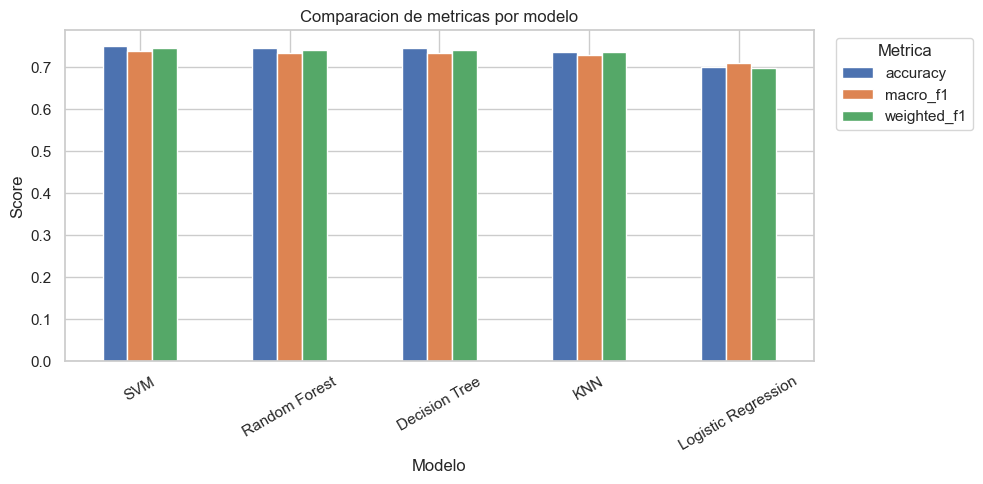

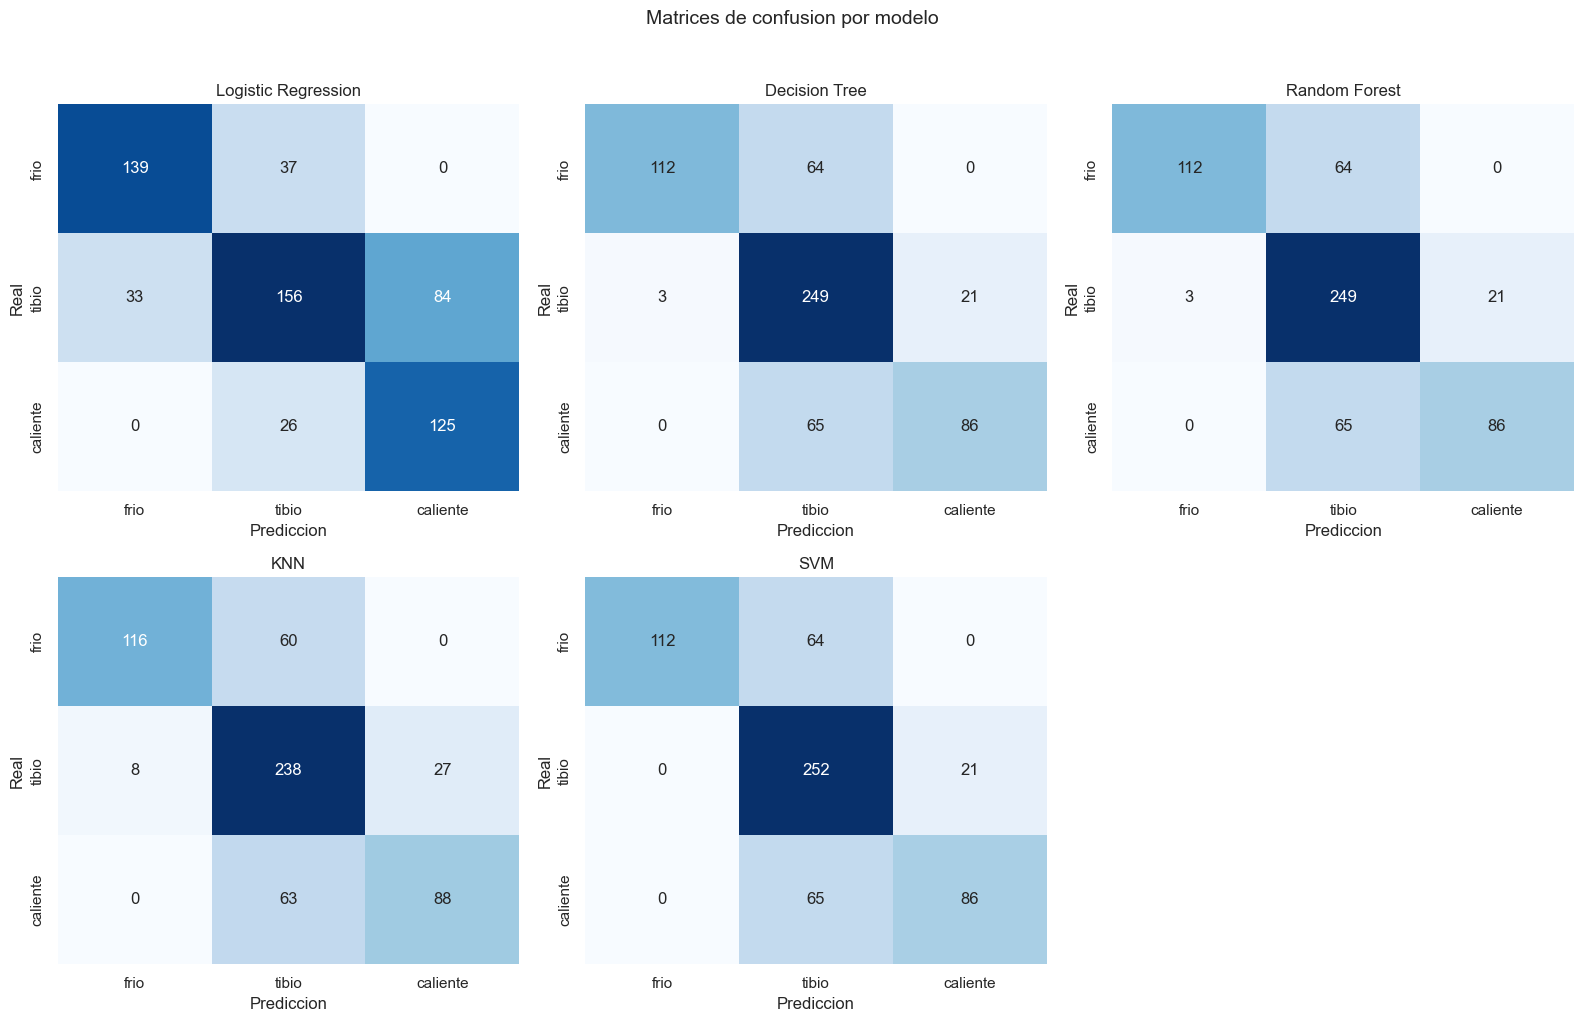

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

sns.set_theme(style='whitegrid')

# 1) Grafica comparativa de metricas globales
ax = summary[['accuracy', 'macro_f1', 'weighted_f1']].plot(
    kind='bar',
    figsize=(10, 5),
    rot=30,
    title='Comparacion de metricas por modelo',
 )
ax.set_ylabel('Score')
ax.set_xlabel('Modelo')
ax.legend(title='Metrica', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 2) Matrices de confusion por modelo
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for i, (model_name, model) in enumerate(models.items()):
    pipe = Pipeline([
        ('prep', preprocessor),
        ('clf', model)
    ])
    pipe.fit(X_train, y_train)
    y_pred_model = pipe.predict(X_test)

    cm = confusion_matrix(y_test, y_pred_model, labels=class_labels)
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        xticklabels=class_names,
        yticklabels=class_names,
        ax=axes[i]
    )
    axes[i].set_title(model_name)
    axes[i].set_xlabel('Prediccion')
    axes[i].set_ylabel('Real')

# Ocultar el subplot sobrante (2x3 para 5 modelos)
axes[-1].axis('off')

plt.suptitle('Matrices de confusion por modelo', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

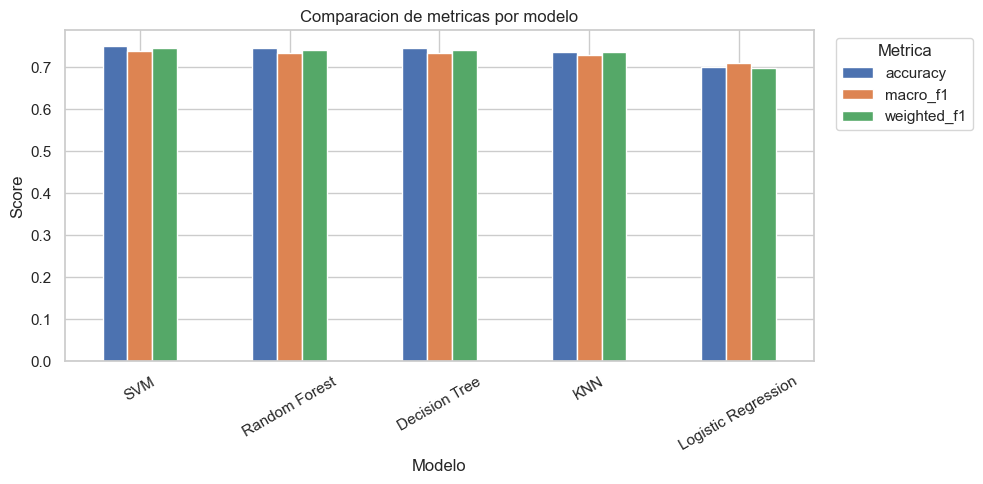

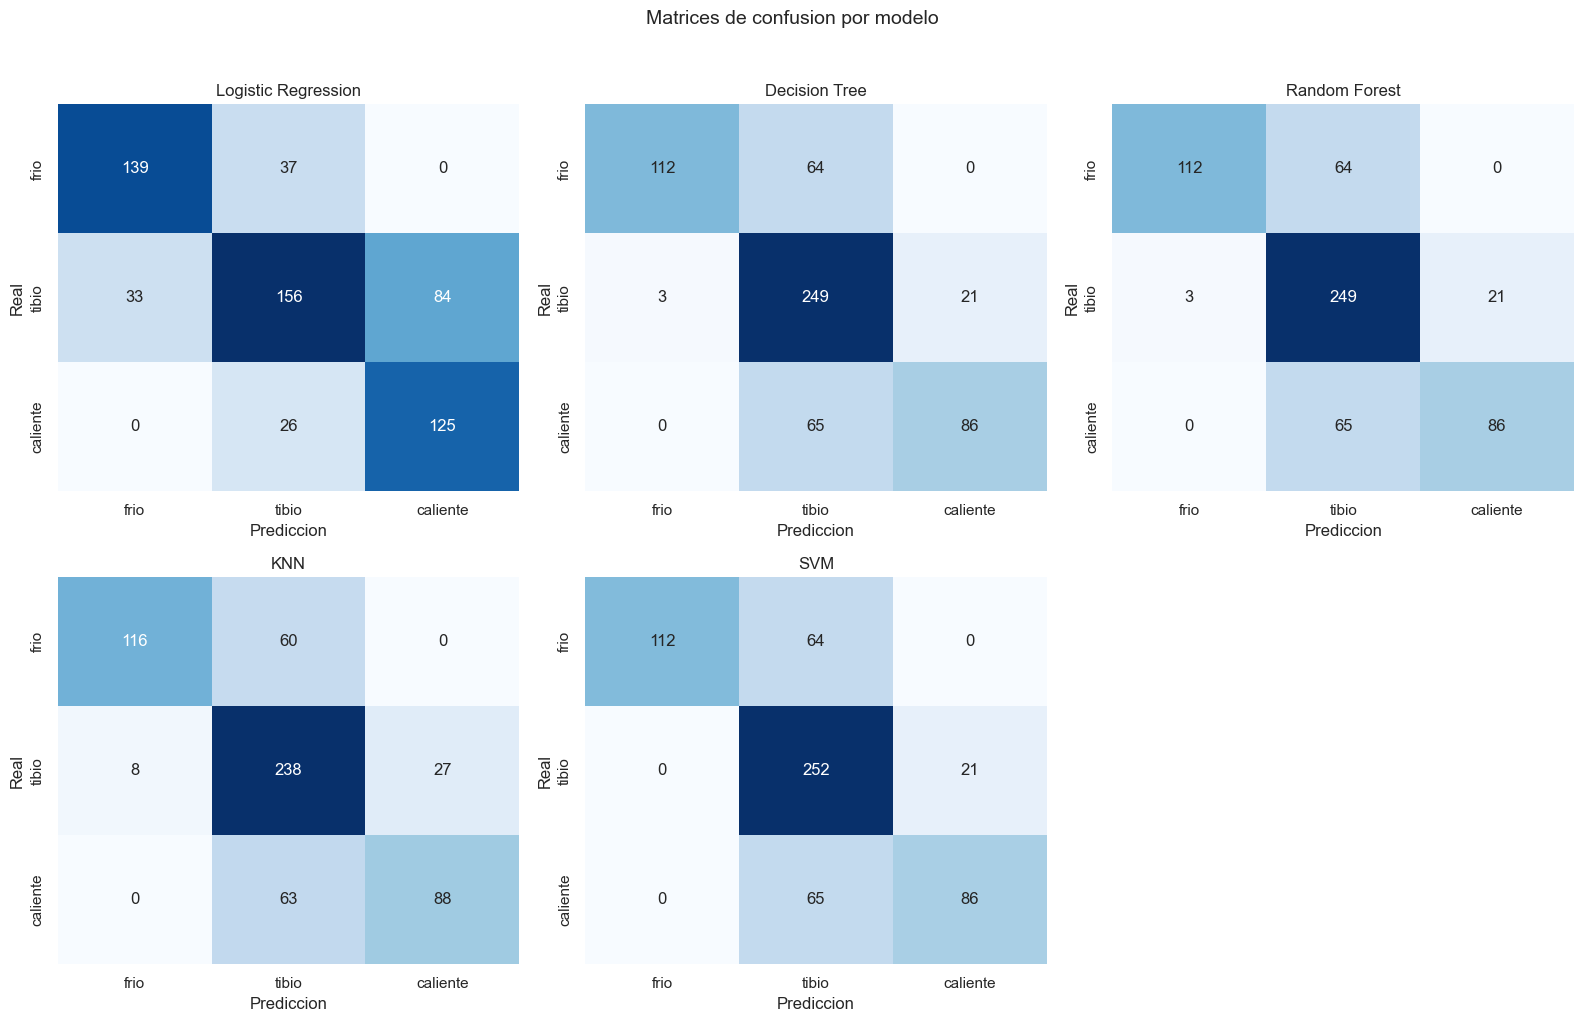

Graficas exportadas en: C:\Users\MARIANA\Desktop\LAIDA\latex\Figures


In [7]:
# Guardar las graficas para el documento LaTeX
from pathlib import Path

figures_dir = Path('../latex/Figures')
figures_dir.mkdir(parents=True, exist_ok=True)

# Grafica 1: comparacion de metricas
ax = summary[['accuracy', 'macro_f1', 'weighted_f1']].plot(
    kind='bar',
    figsize=(10, 5),
    rot=30,
    title='Comparacion de metricas por modelo',
 )
ax.set_ylabel('Score')
ax.set_xlabel('Modelo')
ax.legend(title='Metrica', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(figures_dir / 'comparacion_metricas_modelos.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# Grafica 2: matrices de confusion
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for i, (model_name, model) in enumerate(models.items()):
    pipe = Pipeline([
        ('prep', preprocessor),
        ('clf', model)
    ])
    pipe.fit(X_train, y_train)
    y_pred_model = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred_model, labels=class_labels)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        xticklabels=class_names,
        yticklabels=class_names,
        ax=axes[i]
    )
    axes[i].set_title(model_name)
    axes[i].set_xlabel('Prediccion')
    axes[i].set_ylabel('Real')

axes[-1].axis('off')
plt.suptitle('Matrices de confusion por modelo', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig(figures_dir / 'matrices_confusion_modelos.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print('Graficas exportadas en:', figures_dir.resolve())

## Graficas del mejor modelo: SVM

En esta seccion se generan visualizaciones especificas del modelo SVM:
1. Matriz de confusion.
2. Curvas ROC multiclase (One-vs-Rest).
3. Metricas por clase (precision, recall y f1-score).

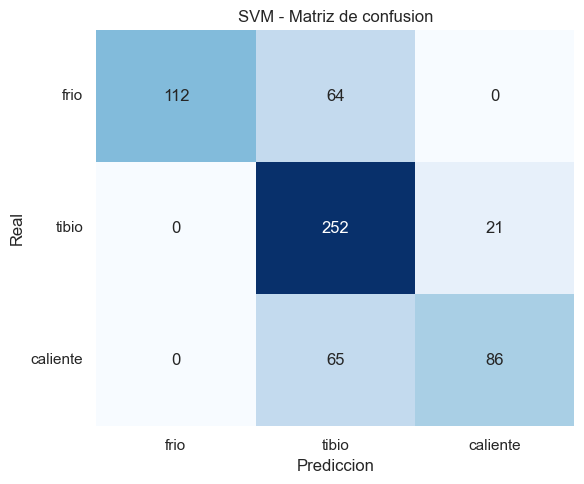

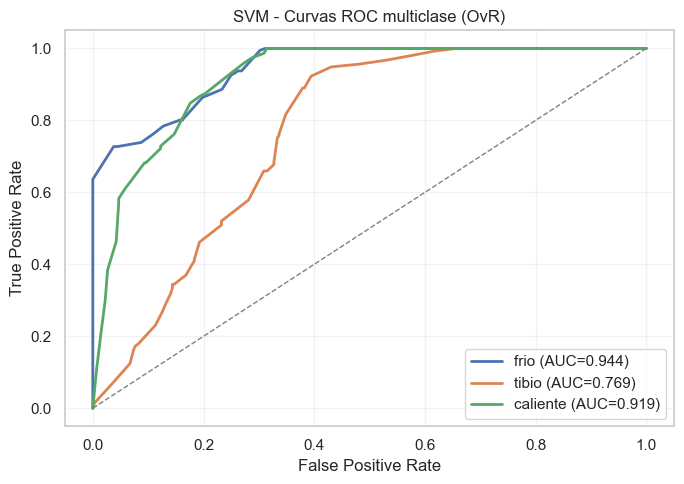

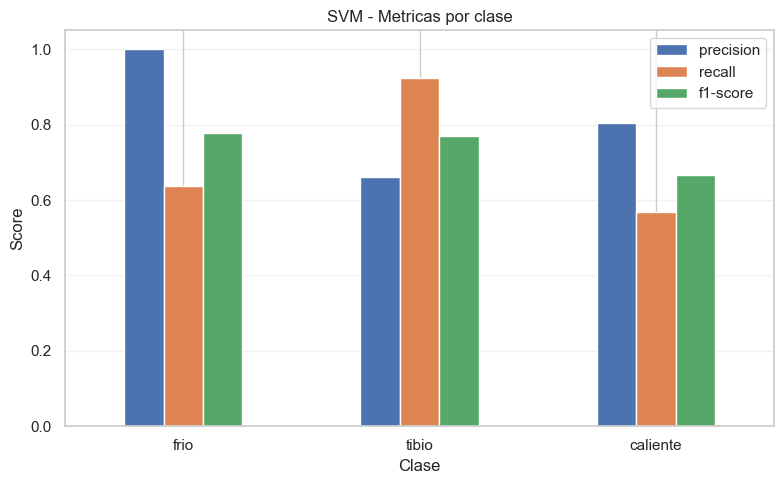

Graficas SVM exportadas en: C:\Users\MARIANA\Desktop\LAIDA\latex\Figures


In [10]:
import numpy as np
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Entrenar nuevamente SVM para analisis dedicado
svm_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', SVC(kernel='linear', decision_function_shape='ovr'))
 ])
svm_pipe.fit(X_train, y_train)
y_pred_svm = svm_pipe.predict(X_test)

# Preparar carpeta de salida para exportar figuras
figures_dir = Path('../latex/Figures')
figures_dir.mkdir(parents=True, exist_ok=True)

# 1) Matriz de confusion SVM
cm_svm = confusion_matrix(y_test, y_pred_svm, labels=class_labels)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm_svm, annot=True, fmt='d', cmap='Blues', cbar=False,
    xticklabels=class_names, yticklabels=class_names, ax=ax
 )
ax.set_title('SVM - Matriz de confusion')
ax.set_xlabel('Prediccion')
ax.set_ylabel('Real')
ax.tick_params(axis='x', labelrotation=0)
ax.tick_params(axis='y', labelrotation=0)
plt.tight_layout()
plt.savefig(figures_dir / 'svm_matriz_confusion.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# 2) ROC multiclase (One-vs-Rest)
classes = svm_pipe.named_steps['clf'].classes_
y_test_bin = label_binarize(y_test, classes=classes)
y_score = svm_pipe.decision_function(X_test)

fig, ax = plt.subplots(figsize=(7, 5))
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    cls_name = CLASS_ID_TO_NAME.get(int(cls), str(cls))
    ax.plot(fpr, tpr, lw=2, label=f'{cls_name} (AUC={roc_auc:.3f})')

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', lw=1)
ax.set_title('SVM - Curvas ROC multiclase (OvR)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.tick_params(axis='both', labelrotation=0)
ax.legend(loc='lower right')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(figures_dir / 'svm_curvas_roc_ovr.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# 3) Metricas por clase
svm_report = classification_report(
    y_test,
    y_pred_svm,
    labels=class_labels,
    target_names=class_names,
    output_dict=True
)
class_metrics = pd.DataFrame({
    name: {
        'precision': svm_report[name]['precision'],
        'recall': svm_report[name]['recall'],
        'f1-score': svm_report[name]['f1-score']
    }
    for name in class_names
}).T

ax = class_metrics.plot(kind='bar', figsize=(8, 5), rot=0)
ax.set_title('SVM - Metricas por clase')
ax.set_xlabel('Clase')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.tick_params(axis='x', labelrotation=0)
ax.tick_params(axis='y', labelrotation=0)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig(figures_dir / 'svm_metricas_por_clase.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print('Graficas SVM exportadas en:', figures_dir.resolve())